In [ ]:
pip install --quiet diffrax

In [ ]:
import diffrax as dx
import jax
import jax.numpy as jnp
from jax.experimental import sparse
import matplotlib.pyplot as plt
import numpy as np

We have the PDE

$\partial_t A = \partial^2_x A +  (A-\alpha)(A-\theta)(1 - A) + B$

$\partial_t B = D_B\partial^2_x B - \varepsilon (B - \mu A B)$

$A(x, 0) = 0$

$B(x, 0) = B_0(x)$

Define parameters

Let's discretize the spatial coordinate over the bounded domain $x\in[-\frac{L}{2}, \frac{L}{2}]$, giving us an $n$-dimensional ODE system for $\mathbf{a}(t) \in \mathbb{R}_+^n$ and $\mathbf{b}(t) \in \mathbb{R}_+^n$, with uniform grid spacing $\delta x = \frac{L}{n}$:

$$
\begin{align}
\mathbf{\dot a} &= \Delta^{(2)} \ \mathbf{a} + (\mathbf{a}-\alpha\mathbf{1})\odot(\mathbf{a}-\theta \mathbf{1})\odot(\mathbf{1} - \mathbf{a}) + \mathbf{b}\\
\mathbf{\dot b} &= \rho \ \Delta^{(2)} \ \mathbf{b} - \varepsilon \ \mathbf{a} \odot \mathbf{b}
\end{align}
$$

with initial conditions

$$
\begin{align}
\mathbf{a}(0) &= \mathbf{0}\\
\mathbf{b}(0) &= \mathbf{b}_0
\end{align}
$$

where $\Delta^{(2)}$ denotes the second-order discrete difference operator

$$
\Delta^{(2)}_{ij} =
\frac{1}{\delta x^2}
\begin{bmatrix}
2 & -5 & 4      & -1     &        &     \\[1mm]
1 & -2 & 1      &        &        &    \\[1mm]
& 1  & -2     & 1      &        &    \\[1mm]
&    & \ddots & \ddots & \ddots &    \\[1mm]
&        &        & 1      & -2 & 1 \\[1mm]
&        &     -1  & 4      & -5 & 2
\end{bmatrix}
$$

Fix discretization

In [ ]:
L = 100.0
n = 1000
δx = L / n

x = jnp.linspace(-L / 2, L / 2, n)

Define finite difference operator

In [ ]:
Δ = jnp.diag(-2 * jnp.ones(n, dtype=int)) + jnp.diag(jnp.ones(n - 1, dtype=int), k=-1) + jnp.diag(jnp.ones(n - 1, dtype=int), k=1)
Δ = Δ.at[0, :4].set([2, -5, 4, -1])
Δ = Δ.at[-1, -4:].set([-1, 4, -5, 2])

Δ


Array([[ 2, -5,  4, ...,  0,  0,  0],
       [ 1, -2,  1, ...,  0,  0,  0],
       [ 0,  1, -2, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ..., -2,  1,  0],
       [ 0,  0,  0, ...,  1, -2,  1],
       [ 0,  0,  0, ...,  4, -5,  2]], dtype=int32)

Scale $\Delta$ according to the grid spacing $\delta x$ and convert to a sparse array.

In [ ]:
Δ = sparse.BCOO.fromdense(Δ / δx)

Define an aggregate vector $\mathbf{y}(t)\in\mathbb{R}^{2n}$ by spatially interleaving elements $\mathbf{a}$ and $\mathbf{b}$

$$
\mathbf{y}(t) = \left[a_1(t), b_1(t), \dots, a_n(t), b_n(t)\right]^{\,\intercal}
$$

then we have an ODE system in standard form

$$
\mathbf{\dot y} = f(t, \mathbf{y}), \quad \mathbf{y}(0) = \mathbf{y}_0
$$

In [ ]:
@jax.jit
def interleave(a, b):
  y = jnp.empty(len(a) + len(b))
  y = y.at[::2].set(a)
  y = y.at[1::2].set(b)
  return y

@jax.jit
def unravel(y):
  return y[::2], y[1::2]


In [ ]:
@jax.jit
def f(t, y, args=[0.1, 0.0, 0.001, 1.0, 0.01, 100.0]):
  θ, ρ, ε, d, α, μ = args

  a, b = unravel(y)

  a_dot = d * Δ @ a + (a - α) * (a - θ) * (1 - a) + b
  b_dot = ρ * Δ @ b - ε * a * b

  return interleave(a_dot, b_dot)

Fix parameters

In [ ]:
θ = 0.1
ρ = 0.0
ε = 0.0
d = 0.0
α = 0.00
μ = 0.0

Fix initial condition

In [ ]:
a0 = jnp.zeros(n)
#a0 = a0.at[n // 2 ].set(1)
b0 = jnp.zeros(n)
b0 = b0.at[n // 2].set(0.01)
#b0 = b0.at[n // 2 - 20].set(1e-2)

y0 = interleave(a0, b0)


Fix a time grid

In [ ]:
t = jnp.linspace(0, 200, 100)

Solve!

In [ ]:
ode_term = dx.ODETerm(f)
rtol = 1e-8
atol = 1e-8
max_steps = 100000
solver = dx.Tsit5()
stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)

solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε, d, α, μ),
                                t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                y0=y0,
                                saveat=dx.SaveAt(ts=t),
                                stepsize_controller=stepsize_controller,
                                max_steps=max_steps
                                )

a, b = unravel(solution.ys.T)

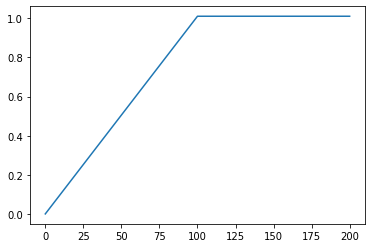

In [ ]:
plt.figure()
plt.plot(t, a[n // 2])

In [ ]:
9 * np.pi * (θ) ** 0.5 / 8 / 0.1

11.176411799020613

In [ ]:
a.shape, b.shape

((1000, 100), (1000, 100))

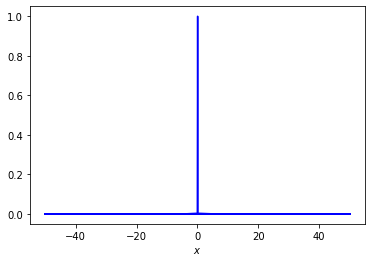

In [ ]:
plt.plot(x, a, "b")
#plt.plot(x, b, "r")
plt.xlabel("$x$")
plt.show()

Text(0.5, 0, 'time')

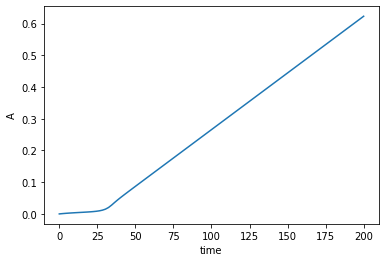

In [ ]:
plt.figure()
plt.plot(t, jnp.mean(a, axis=0))
plt.ylabel('A')
plt.xlabel('time')

In [ ]:
def stretch_kymograph(k, factor):
    """stretch kymograph along horizontal axix by factor"""
    factor = int(factor)
    stretched = np.zeros((k.shape[0], k.shape[1] * factor))
    for i in range(k.shape[1]):
        stretched[:, factor * i : factor * (i+1)] = np.repeat(np.expand_dims(k[:, i], axis=1), factor, axis=1)

    return stretched

Text(0.5, 1.0, 'A over x and t')

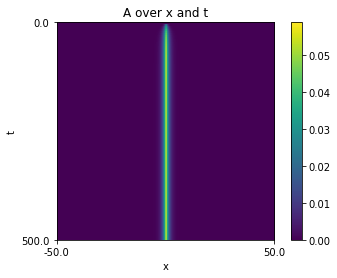

In [ ]:
anp = np.array(a)
factor = 10
stretched = stretch_kymograph(anp, factor=factor)
plt.figure()
plt.imshow(stretched.T)
plt.xlabel('x')
plt.ylabel('t')
plt.yticks([0,  stretched.shape[0]], labels=[t[0], t[-1]])
plt.xticks([0, stretched.shape[1]], labels=[x[0], x[-1]])
plt.colorbar()
plt.title('A over x and t')

In [ ]:
a.shape

(1000, 100)

# input-output analysis

In [ ]:
def coarse_production_rate(a, t):
  mean_a = np.mean(a, axis=0)
  coarse_production_rate = (mean_a[-1] - mean_a[0]) / (t[-1] - t[0])

  return coarse_production_rate

In [ ]:
slope = coarse_production_rate(a, t)
print(slope)

3.1160667


Now let's loop over initial condition and plot slope as a function of B0

In [ ]:
num_B0s = 50
B0_arr = np.linspace(0.01, 0.3, num_B0s)
rtol = 1e-8
atol = 1e-8
max_steps = 100000
solver = dx.Tsit5()
stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)
t = jnp.linspace(0, 200, 100)
ε = 0.0
slopes = np.zeros_like(B0_arr)
for i in range(len(B0_arr)):
  print(f'{i+1} of {len(B0_arr)}')
  a0 = jnp.zeros(n)
  b0 = jnp.zeros(n)
  b0 = b0.at[n // 2].set(B0_arr[i])
  y0 = interleave(a0, b0)
  ode_term = dx.ODETerm(f)
  solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε),
                                t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                y0=y0,
                                saveat=dx.SaveAt(ts=t),
                                stepsize_controller=stepsize_controller,
                                max_steps=max_steps
                                )
  a, b = unravel(solution.ys.T)
  slope = coarse_production_rate(a, t)
  slopes[i] = slope




1 of 50
2 of 50
3 of 50
4 of 50
5 of 50
6 of 50
7 of 50
8 of 50
9 of 50
10 of 50
11 of 50
12 of 50
13 of 50
14 of 50
15 of 50
16 of 50
17 of 50
18 of 50
19 of 50
20 of 50
21 of 50
22 of 50
23 of 50
24 of 50
25 of 50
26 of 50
27 of 50
28 of 50
29 of 50
30 of 50
31 of 50
32 of 50
33 of 50
34 of 50
35 of 50
36 of 50
37 of 50
38 of 50
39 of 50
40 of 50
41 of 50
42 of 50
43 of 50
44 of 50
45 of 50
46 of 50
47 of 50
48 of 50
49 of 50
50 of 50


Text(0.5, 1.0, 'long-run A production rate vs B0, $\\epsilon=1$')

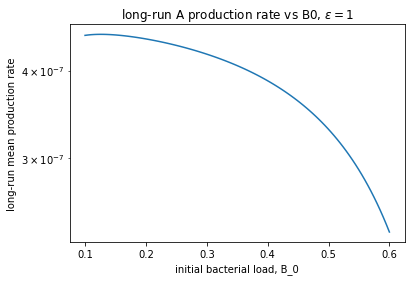

In [ ]:
plt.figure()
plt.plot(B0_arr, slopes)
plt.yscale('log')
plt.xlabel('initial bacterial load, B_0')
plt.ylabel('long-run mean production rate')
plt.title('long-run A production rate vs B0, $\epsilon=1$')

In [ ]:
slopes_space=slopes

Text(0.5, 1.0, 'long-run A production rate vs B0, $\\epsilon=0$')

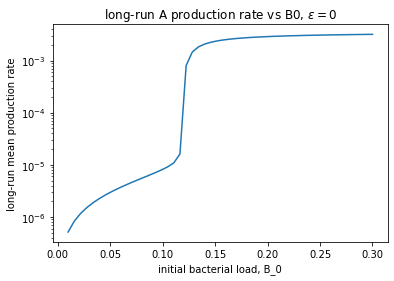

In [ ]:
plt.figure()
plt.plot(B0_arr, slopes_space)
plt.yscale('log')
plt.xlabel('initial bacterial load, B_0')
plt.ylabel('long-run mean production rate')
plt.title('long-run A production rate vs B0, $\epsilon=0$')

Now let's look at the single cell response. Manually set the A diffusion coefficient to zero above.

In [ ]:
def single_cell_coarse_rate(a, t, idx):
  this_cell = a[idx, :]
  slope = (this_cell[-1] - this_cell[0]) / (t[-1] - t[0])

  return slope

In [ ]:
num_B0s = 50
B0_arr = np.linspace(0.001, 0.01, num_B0s)
rtol = 1e-8
atol = 1e-8
max_steps = 100000
solver = dx.Tsit5()
stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)
t = jnp.linspace(0, 200, 100)
ε = 0
slopes = np.zeros_like(B0_arr)
for i in range(len(B0_arr)):
  print(f'{i+1} of {len(B0_arr)}')
  a0 = jnp.zeros(n)
  b0 = jnp.zeros(n)
  b0 = b0.at[n // 2].set(B0_arr[i])
  y0 = interleave(a0, b0)
  ode_term = dx.ODETerm(f)
  solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε),
                                t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                y0=y0,
                                saveat=dx.SaveAt(ts=t),
                                stepsize_controller=stepsize_controller,
                                max_steps=max_steps
                                )
  a, b = unravel(solution.ys.T)
  slope = single_cell_coarse_rate(a, t, idx=n // 2)
  slopes[i] = slope


1 of 50
2 of 50
3 of 50
4 of 50
5 of 50
6 of 50
7 of 50
8 of 50
9 of 50
10 of 50
11 of 50
12 of 50
13 of 50
14 of 50
15 of 50
16 of 50
17 of 50
18 of 50
19 of 50
20 of 50
21 of 50
22 of 50
23 of 50
24 of 50
25 of 50
26 of 50
27 of 50
28 of 50
29 of 50
30 of 50
31 of 50
32 of 50
33 of 50
34 of 50
35 of 50
36 of 50
37 of 50
38 of 50
39 of 50
40 of 50
41 of 50
42 of 50
43 of 50
44 of 50
45 of 50
46 of 50
47 of 50
48 of 50
49 of 50
50 of 50


In [ ]:
slopes_single = slopes
B0_arr_single = np.linspace(0.001, 0.01, num_B0s)
B0_arr_spatial = np.linspace(0.01, 0.3, num_B0s)


Text(0.5, 1.0, 'single cell long-run A production rate vs B0, $\\epsilon=0$')

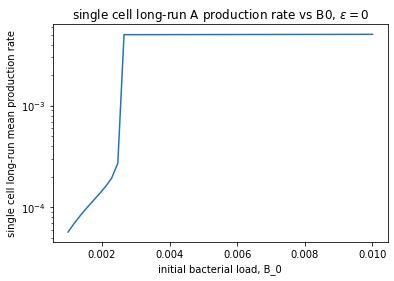

In [ ]:
plt.figure()
plt.plot(B0_arr, slopes_single)
plt.yscale('log')
plt.xlabel('initial bacterial load, B_0')
plt.ylabel('single cell long-run mean production rate')
plt.title('single cell long-run A production rate vs B0, $\epsilon=0$')

In [ ]:
def predicted_threshold_zeroth_order(theta):
  return theta ** 2 / (4 * (1 + theta))

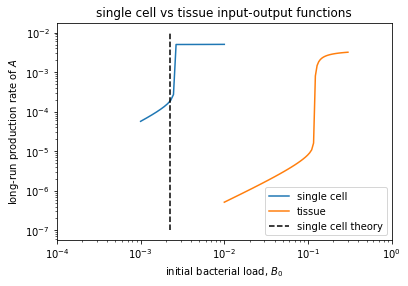

In [ ]:
# one plot containing single cell and all cells
plt.figure()
plt.plot(B0_arr_single, slopes_single, label='single cell')
plt.plot(B0_arr_spatial, slopes_space, label='tissue')
prediction = predicted_threshold_zeroth_order(θ)
plt.plot(prediction * np.ones(5), np.logspace(-7, -2, 5), 'k--', label='single cell theory')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('initial bacterial load, $B_0$')
plt.ylabel('long-run production rate of $A$')
plt.xlim([1e-4, 1e0])
plt.title('single cell vs tissue input-output functions')
plt.legend()

In [ ]:
a.shape

(1000, 100)

# Input-Output functions v2

What if output is just spatial average A as t --> infinity.

In [ ]:
num_B0s = 50
B0_arr = np.linspace(0.01, 0.3, num_B0s)
rtol = 1e-8
atol = 1e-8
max_steps = 100000
solver = dx.Tsit5()
stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)
t = jnp.linspace(0, 500, 100)
ε = 0.0
Amean_spatial = np.zeros_like(B0_arr)
for i in range(len(B0_arr)):
  print(f'{i+1} of {len(B0_arr)}')
  a0 = jnp.zeros(n)
  b0 = jnp.zeros(n)
  b0 = b0.at[n // 2].set(B0_arr[i])
  y0 = interleave(a0, b0)
  ode_term = dx.ODETerm(f)
  solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε),
                                t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                y0=y0,
                                saveat=dx.SaveAt(ts=t),
                                stepsize_controller=stepsize_controller,
                                max_steps=max_steps
                                )
  a, b = unravel(solution.ys.T)
  Amean_spatial[i] = np.mean(a[:, -1])

B0_spatial = B0_arr

1 of 50
2 of 50
3 of 50
4 of 50
5 of 50
6 of 50
7 of 50
8 of 50
9 of 50
10 of 50
11 of 50
12 of 50
13 of 50
14 of 50
15 of 50
16 of 50
17 of 50
18 of 50
19 of 50
20 of 50
21 of 50
22 of 50
23 of 50
24 of 50
25 of 50
26 of 50
27 of 50
28 of 50
29 of 50
30 of 50
31 of 50
32 of 50
33 of 50
34 of 50
35 of 50
36 of 50
37 of 50
38 of 50
39 of 50
40 of 50
41 of 50
42 of 50
43 of 50
44 of 50
45 of 50
46 of 50
47 of 50
48 of 50
49 of 50
50 of 50


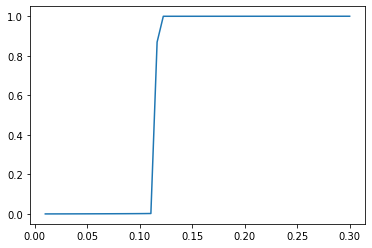

In [ ]:
plt.figure()
plt.plot(B0_spatial, Amean_spatial)

In [ ]:
9 / (4 / np.pi - 1) /8

4.117266412116172

In [ ]:
np.sqrt(0.1) * 3 * np.pi / 8

0.37254705996735377

Single cell

In [ ]:
num_B0s = 50
B0_arr = np.linspace(0.001, 0.01, num_B0s)
rtol = 1e-8
atol = 1e-8
max_steps = 100000
solver = dx.Tsit5()
stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)
t = jnp.linspace(0, 500, 100)
ε = 0.0
A_single = np.zeros_like(B0_arr)
for i in range(len(B0_arr)):
  print(f'{i+1} of {len(B0_arr)}')
  a0 = jnp.zeros(n)
  b0 = jnp.zeros(n)
  b0 = b0.at[n // 2].set(B0_arr[i])
  y0 = interleave(a0, b0)
  ode_term = dx.ODETerm(f)
  solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε),
                                t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                y0=y0,
                                saveat=dx.SaveAt(ts=t),
                                stepsize_controller=stepsize_controller,
                                max_steps=max_steps
                                )
  a, b = unravel(solution.ys.T)
  A_single[i] = a[n // 2, -1]

B0_single = B0_arr

1 of 50
2 of 50
3 of 50
4 of 50
5 of 50
6 of 50
7 of 50
8 of 50
9 of 50
10 of 50
11 of 50
12 of 50
13 of 50
14 of 50
15 of 50
16 of 50
17 of 50
18 of 50
19 of 50
20 of 50
21 of 50
22 of 50
23 of 50
24 of 50
25 of 50
26 of 50
27 of 50
28 of 50
29 of 50
30 of 50
31 of 50
32 of 50
33 of 50
34 of 50
35 of 50
36 of 50
37 of 50
38 of 50
39 of 50
40 of 50
41 of 50
42 of 50
43 of 50
44 of 50
45 of 50
46 of 50
47 of 50
48 of 50
49 of 50
50 of 50


Text(0.5, 1.0, 'input-output functions at cellular and tissue scales (steady state)')

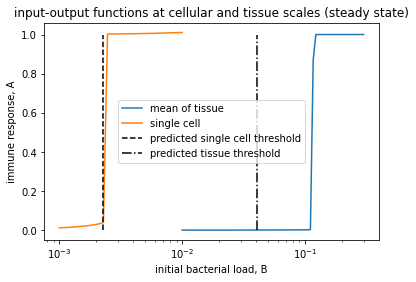

In [ ]:
# one plot with single cell and mean tissue
plt.figure()
plt.plot(B0_spatial, Amean_spatial, label='mean of tissue')
plt.plot(B0_single, A_single, label='single cell')
prediction = predicted_threshold_zeroth_order(θ)
plt.plot(prediction * np.ones(5), np.linspace(0, 1, 5), 'k--', label='predicted single cell threshold')
tissue_prediction = ((3 * np.pi * θ) / 8) ** 1.5
plt.plot(tissue_prediction * np.ones(5), np.linspace(0, 1, 5), 'k-.', label='predicted tissue threshold')

plt.xlabel('initial bacterial load, B')
plt.ylabel('immune response, A')
plt.xscale('log')
plt.legend()
plt.title('input-output functions at cellular and tissue scales (steady state)')

In [ ]:
θ ** 1.5

0.0316227766016838

In [ ]:
((3 * np.pi * 0.2) / 8) ** 1.5

0.11437120692946055

In [ ]:
from tqdm import tqdm

In [ ]:
def compare_thresholds_single_vs_tissue(B0_single, B0_spatial, t, θ=0.1, ε=0.0, α=0.00, μ=0.0, ρ=0.0):
  # fixed params
  rtol = 1e-8
  atol = 1e-8
  max_steps = 100000
  solver = dx.Tsit5()
  stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)
  wing = 5

  # single
  A_single = np.zeros_like(B0_single)
  d = 0.0
  for i in tqdm(range(len(B0_single))):
    #print(f'{i+1} of {len(B0_single)}')
    a0 = jnp.zeros(n)
    b0 = jnp.zeros(n)
    b0 = b0.at[n // 2].set(B0_single[i])
    y0 = interleave(a0, b0)
    ode_term = dx.ODETerm(f)
    solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε, d, α, μ),
                                  t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                  y0=y0,
                                  saveat=dx.SaveAt(ts=t),
                                  stepsize_controller=stepsize_controller,
                                  max_steps=max_steps
                                  )
    a, b = unravel(solution.ys.T)
    A_single[i] = a[n // 2, -1]

  # tissue
  Amean_spatial = np.zeros_like(B0_spatial)
  d = 1.0
  for i in tqdm(range(len(B0_spatial))):
    #print(f'{i+1} of {len(B0_spatial)}')
    a0 = jnp.zeros(n)
    b0 = jnp.zeros(n)
    #b0 = b0.at[n // 2].set(B0_spatial[i])
    b0 = b0.at[n // 2 - wing:n // 2 + wing].set(B0_spatial[i])

    y0 = interleave(a0, b0)
    ode_term = dx.ODETerm(f)
    solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε, d, α, μ),
                                  t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                  y0=y0,
                                  saveat=dx.SaveAt(ts=t),
                                  stepsize_controller=stepsize_controller,
                                  max_steps=max_steps
                                  )
    a, b = unravel(solution.ys.T)
    Amean_spatial[i] = np.mean(a[:, -1])

  return A_single, Amean_spatial


def measure_threshold(A, B0):
  tmp = B0[:-1]
  threshold = tmp[np.diff(A) == np.max(np.diff(A))]

  return threshold


In [ ]:
num_B0s = 50
B0_single = np.logspace(-5, -3, num_B0s)
B0_spatial = np.logspace(-3, -1, num_B0s)
ε = 0.0
α=0.0
μ=0.0
ρ= 0.0
θ= 0.01
t = jnp.linspace(0, 1000, 3)

A_single, Amean_spatial = compare_thresholds_single_vs_tissue(B0_single, B0_spatial, t, θ=θ, ε=ε, α=α, μ=μ, ρ=ρ)

100%|██████████| 50/50 [06:44<00:00,  8.08s/it]


In [ ]:
from matplotlib import rc

In [ ]:
rc('axes', linewidth=4)

NameError: ignored

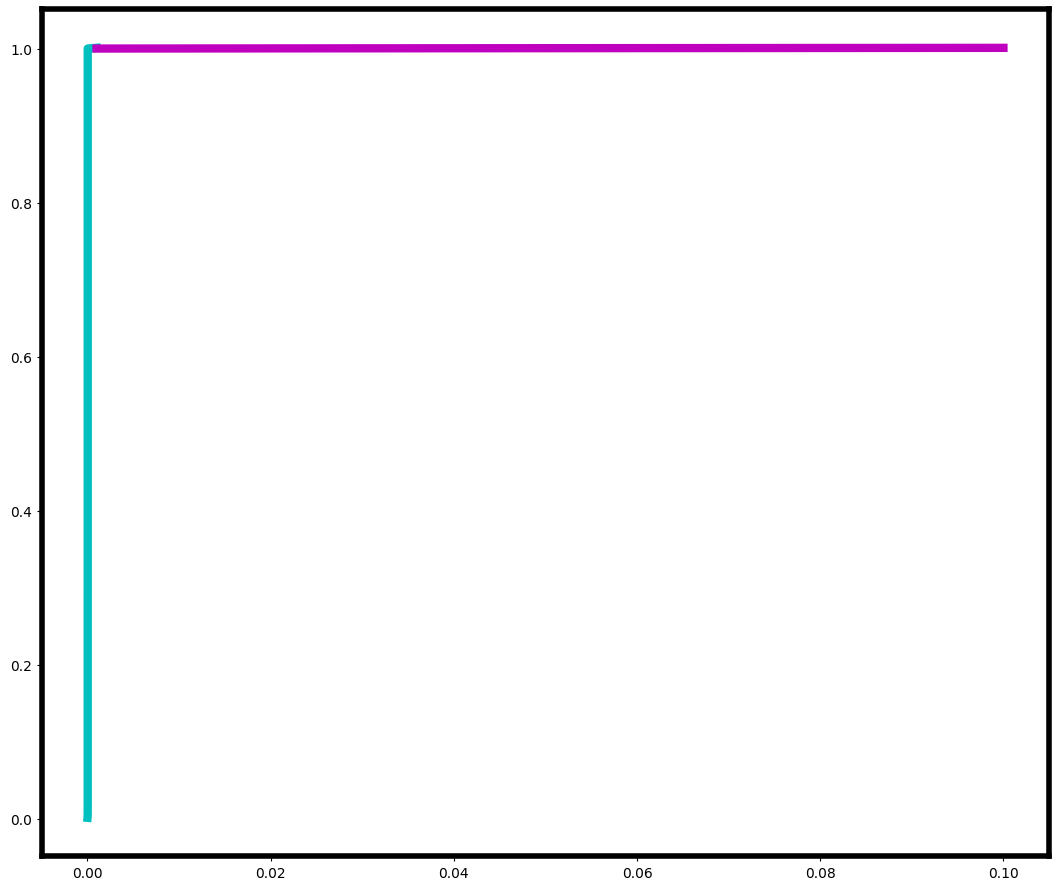

In [ ]:

# one plot with single cell and mean tissue
plt.figure(figsize=(13,11))
plt.plot(B0_single, A_single, label='single cell', linewidth=6, color='c')
plt.plot(B0_spatial, Amean_spatial, label='mean of tissue', linewidth=6, color='m')
prediction = predicted_threshold_zeroth_order(θ)
plt.plot(prediction * np.ones(5), np.linspace(0, 1, 5), 'w--', label='cell, theory', linewidth=6)
#tissue_prediction = ((9 * np.pi) / 8 / δx) * θ ** 1.5
tissue_prediction = ((9 * np.pi) / 8 / 10) * θ ** 1.5

plt.plot(tissue_prediction * np.ones(5), np.linspace(0, 1, 5), 'w', label='tissue, theory', linestyle='dotted', linewidth=6)

plt.xlabel('initial bacterial load, $B_0$', fontsize=48)
plt.ylabel('immune response, A', fontsize=48)
plt.xscale('log')
plt.legend(fontsize=24, loc=2)
plt.yticks([0, 0.5, 1.0], fontsize=48)
plt.xticks([1e-4, 1e-3, 1e-2, 1e-1], fontsize=48)
plt.minorticks_off()
#plt.title('input-output functions at cellular and tissue scales (steady state)')
plt.tight_layout()
#plt.savefig('A_vs_B0.png')


In [ ]:
df = pd.DataFrame()
df['B0_cell'] = B0_single
df['B0_tissue'] = B0_spatial
df['A_cell'] = A_single
df['A_tissue'] = Amean_spatial
df.to_pickle('A_vs_B0.pkl')

In [ ]:
tmp = B0_single[:-1]
tmp[np.diff(A_single) == np.max(np.diff(A_single))]

array([0.00255102])

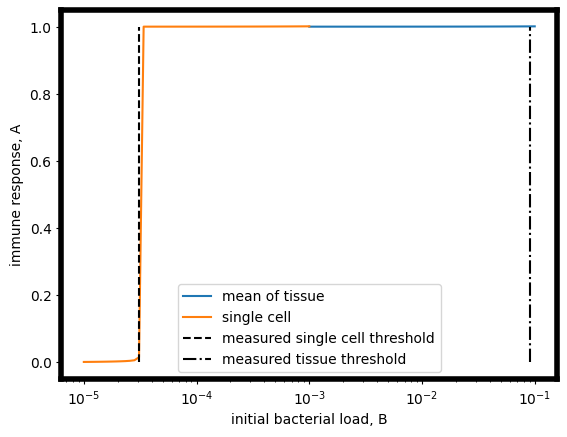

In [ ]:
thresh_single = measure_threshold(A_single, B0_single)
thresh_spatial = measure_threshold(Amean_spatial, B0_spatial)

# one plot with single cell and mean tissue
plt.figure()
plt.plot(B0_spatial, Amean_spatial, label='mean of tissue')
plt.plot(B0_single, A_single, label='single cell')
#prediction = predicted_threshold_zeroth_order(theta_arr[i])
plt.plot(thresh_single * np.ones(5), np.linspace(0, 1, 5), 'k--', label='measured single cell threshold')
#tissue_prediction = ((9 * np.pi) / 8 / δx) * theta_arr[i] ** 1.5
plt.plot(thresh_spatial * np.ones(5), np.linspace(0, 1, 5), 'k-.', label='measured tissue threshold')

plt.xlabel('initial bacterial load, B')
plt.ylabel('immune response, A')
plt.xscale('log')
plt.legend()


In [ ]:
thresh_single

array([3.0888436e-05])

In [ ]:
0.01 ** 2 / 4

2.5e-05

# Derivation of the wave critical threshold

Idris and Biktashev, PRL (2008), consider

$\partial_t A = \partial^2_x A + A(A-\theta)(1-A)$,

with initial condition

$A(x,0) = A_s\Theta(x - x_s)$.

They find that the critical threshold occurs on the function

$A_s = \frac{9\theta}{8}\left[\frac{2}{\pi}\text{tanh}\frac{x_s\sqrt{\theta}}{2}\text{sech}\frac{x_s\sqrt{\theta}}{2} + \frac{4}{\pi}\text{arctan}\left(e^{x_s\sqrt{\theta}/2}\right) - 1\right] ^ {-1}$

Let's work in the limit $\theta \to 0$. Then we can use the limits

$\text{tanh}\,x \to x$

$\text{sech}\,x \to 1$

$\text{arctan}\,e^x \to \frac{\pi}{4}$

and find

$A_s \approx \frac{9\theta}{8}\frac{\pi}{x_s\sqrt{\theta}} = \frac{9\pi}{8x_s}\sqrt{\theta}$.

Now we want to use this result to estimate the critical $B_0$ in our model, where $A_s=0$ but there is coupling to $B$. In the same vein as above, we will look for the $B_0$ such that $A$ hits $A_s$, and we will use the linearization of the $A$ equation,

$\dot{A} = -\theta A + B_0$.

As above, we find

$A = A_s = \frac{B_0}{\theta}$

and so

$B_0 \approx \frac{9\pi}{8x_s}\theta^{3/2}$.

So to summarize we find that the critical $B_0$ value for a single cell to activate scales as

$B_{0, c}^{cell} \sim \theta ^ 2$

and for tissues

$B_{0, c}^{tissue} \sim \theta ^{3/2}$.


For the $x_s$ value: kn our simulations above, we initial $B$ at just one grid point, and the grid points typically have size $\delta x = 0.1$.





In [ ]:
90 * np.pi * (0.1) ** 1.5 / 8

1.1176411799020616

In [ ]:
90 * np.pi * (0.1) ** 0.5 / 8

11.176411799020615

# Testing the scaling of $B_{0,c}$ with $\theta$

100%|██████████| 50/50 [02:35<00:00,  3.11s/it]


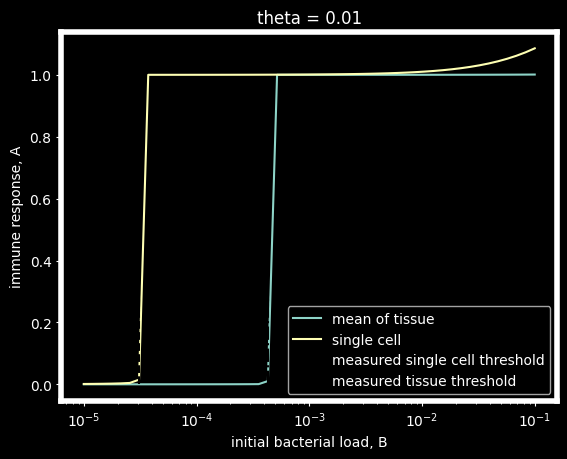

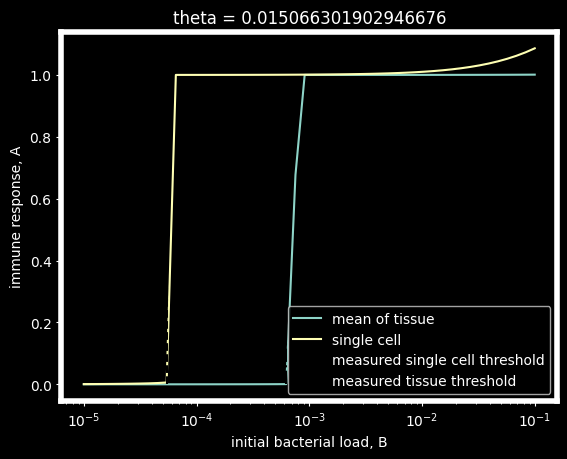

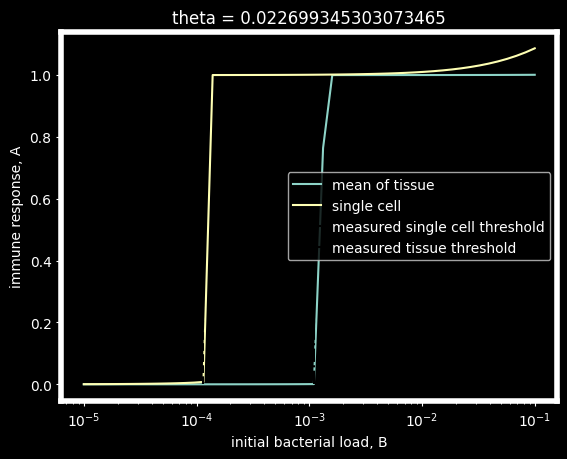

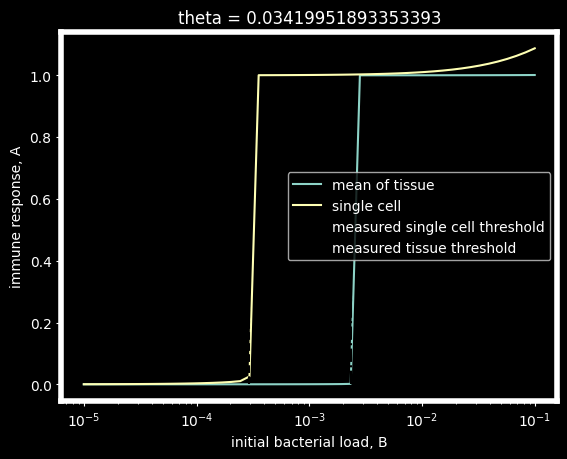

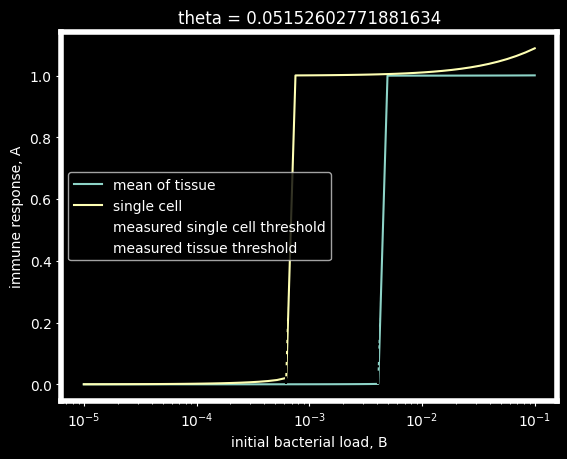

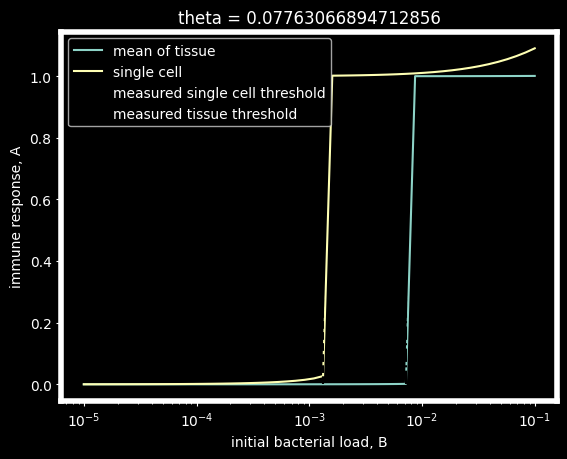

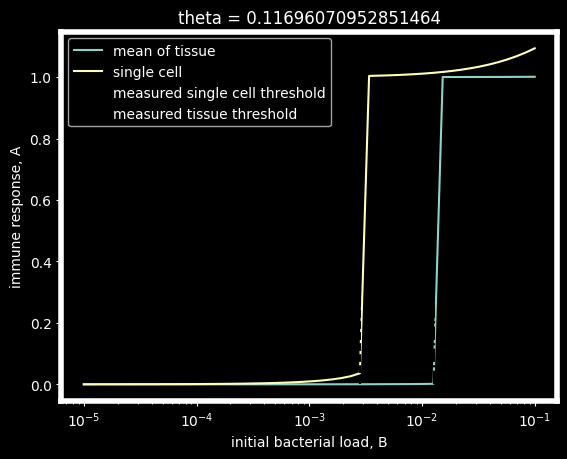

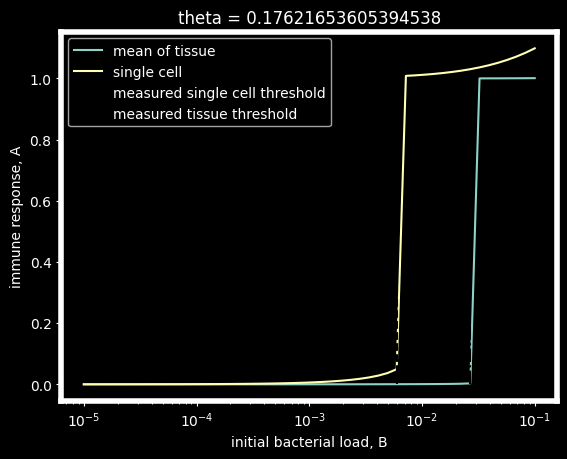

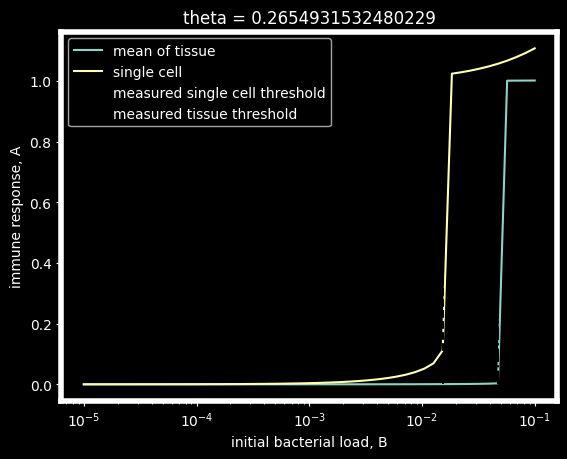

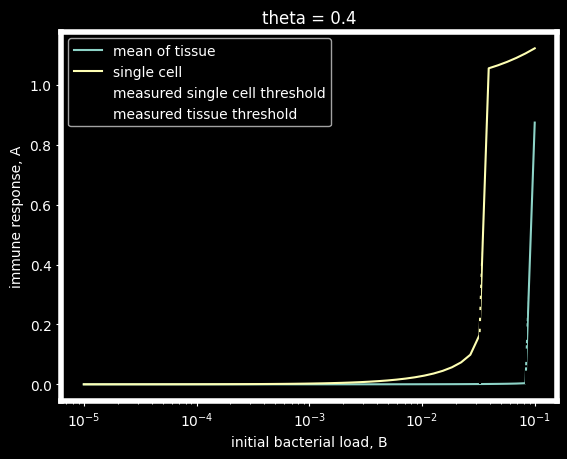

In [ ]:
num_B0s = 50
ε = 0.0
α=0.0
μ=0.0
ρ= 0.0
t = jnp.linspace(0, 1000, 3)
theta_arr = np.logspace(-2, np.log10(0.4), 10)
thresh_single = np.zeros_like(theta_arr)
thresh_spatial = np.zeros_like(theta_arr)
B0_single = np.logspace(-5, -1, num_B0s)
B0_spatial = np.logspace(-5, -1, num_B0s)

for i in range(len(theta_arr)):
  #print(f'{i} of {len(theta_arr)}')
  #predicted_single_thresh = predicted_threshold_zeroth_order(theta_arr[i])
  #B0_single = np.logspace(np.log10(predicted_single_thresh) - 1, np.log10(predicted_single_thresh) + 1, num_B0s)

  #predicted_tissue_thresh = (90 * np.pi) * theta_arr[i] ** 1.5 / 8
  #B0_spatial = np.logspace(np.log10(predicted_tissue_thresh) - 2, np.log10(predicted_tissue_thresh) + 0.5, num_B0s)

  A_single, Amean_spatial = compare_thresholds_single_vs_tissue(B0_single, B0_spatial, t, θ=theta_arr[i], ε=ε, α=α, μ=μ, ρ=ρ)

  thresh_single[i] = measure_threshold(A_single, B0_single)
  thresh_spatial[i] = measure_threshold(Amean_spatial, B0_spatial)

  # one plot with single cell and mean tissue
  plt.figure()
  plt.plot(B0_spatial, Amean_spatial, label='mean of tissue')
  plt.plot(B0_single, A_single, label='single cell')
  #prediction = predicted_threshold_zeroth_order(theta_arr[i])
  plt.plot(thresh_single[i] * np.ones(5), np.linspace(0, 1, 5), 'k--', label='measured single cell threshold')
  #tissue_prediction = ((9 * np.pi) / 8 / δx) * theta_arr[i] ** 1.5
  plt.plot(thresh_spatial[i] * np.ones(5), np.linspace(0, 1, 5), 'k-.', label='measured tissue threshold')

  plt.xlabel('initial bacterial load, B')
  plt.ylabel('immune response, A')
  plt.xscale('log')
  plt.legend()
  plt.title(f'theta = {theta_arr[i]}')



df = pd.DataFrame()
df['theta'] = theta_arr
df['B0c_cell'] = thresh_single
df['B0c_tissue'] = thresh_spatial
df.to_pickle(r'/B0c_vs_theta_t1000.pkl')



In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame()
df['theta'] = theta_arr
df['B0c_cell'] = thresh_single
df['B0c_tissue'] = thresh_spatial
df.to_pickle(r'/B0c_vs_theta.pkl')

In [ ]:
df

,theta,B0c_cell,B0c_tissue
0,0.010000,0.000115,0.001099
1,0.015066,0.000168,0.001600
2,0.022699,0.000244,0.001931
3,0.034200,0.000429,0.003393
4,0.051526,0.000754,0.004942
5,0.077631,0.001600,0.008685
6,0.116961,0.003393,0.015264
7,0.176217,0.007197,0.026827
8,0.265493,0.015264,0.047149
9,0.400000,0.032375,0.082864


In [ ]:
plt.style.use('dark_background')

In [ ]:
df = pd.read_pickle('/B0c_vs_theta_t1000.pkl')
theta_arr = df.theta
thresh_single = df.B0c_cell
thresh_spatial = df.B0c_tissue

plt.figure(figsize=(13,11))
plot_from = 0
#plt.plot(theta_arr[plot_from:], thresh_single[plot_from:], label='cell, numerical', linewidth=6, color='c')
#plt.plot(theta_arr[plot_from:], thresh_spatial[plot_from:], label='tissue, numerical', linewidth=6, color='m')
plt.plot(theta_arr[plot_from:], thresh_single[plot_from:], 'co', markersize=12, label='cell, numerical', linewidth=3, color='c', markerfacecolor='none')
plt.plot(theta_arr[plot_from:], thresh_spatial[plot_from:], 'mo', label='tissue, numerical', linewidth=3, color='m', markerfacecolor='none')
line_single = theta_arr[plot_from:] ** 2 / 4
line_tissue = ((9 * np.pi) / 8 / 10) * theta_arr[plot_from:] ** 1.5
plt.plot(theta_arr[plot_from:], line_single, 'w--', label='cell, theory', linewidth=6)
plt.plot(theta_arr[plot_from:], line_tissue, 'w', label='tissue, theory', linewidth=6, linestyle='dotted')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('positive feedback threshold, $\\theta$', fontsize=48)
plt.ylabel('critical bacterial load, $B_{0,c}$', fontsize=48)
plt.minorticks_off()
plt.legend(fontsize=32)
plt.yticks([1e-4, 1e-2], fontsize=48)
plt.xticks(fontsize=48)
plt.tight_layout()
#plt.savefig('B0c_vs_theta.png')

FileNotFoundError: ignored

In [ ]:
%matplotlib inline

In [ ]:
def fit_line(x, y):
  assert len(y)==len(x)
  slope = (len(x) * np.sum(y * x) - np.sum(x) * np.sum(y)) / (len(x) * np.sum(x * x) - np.sum(x) ** 2)
  intercept = (np.sum(y) - slope * np.sum(x)) / len(x)

  return slope, intercept

In [ ]:
slope_single, intercept_single = fit_line(np.log10(theta_arr[5:]), np.log10(thresh_single[5:]))
slope_spatial, intercept_spatial = fit_line(np.log10(theta_arr[5:]), np.log10(thresh_spatial[5:]))

print(slope_single)
print(slope_spatial)


1.7576341064377314
1.298813958170856


## actual numerical solution of the single cell critical B0 via root finding of the cubic equations

In [ ]:
theta_arr = np.logspace(-2, np.log10(0.4), 500)
B0_arr = np.logspace(-5, -1, 500)
n_real_roots = np.zeros((len(theta_arr), len(B0_arr)))
for i in range(len(theta_arr)):
  for j in range(len(B0_arr)):
    p = (B0_arr[j], -theta_arr[i], 1+theta_arr[i], -1)
    roots = np.roots(p)
    n_real_roots[i,j] = np.sum(np.isreal(roots))

In [ ]:
import matplotlib.pyplot as plt

(-5.0, -1.0)

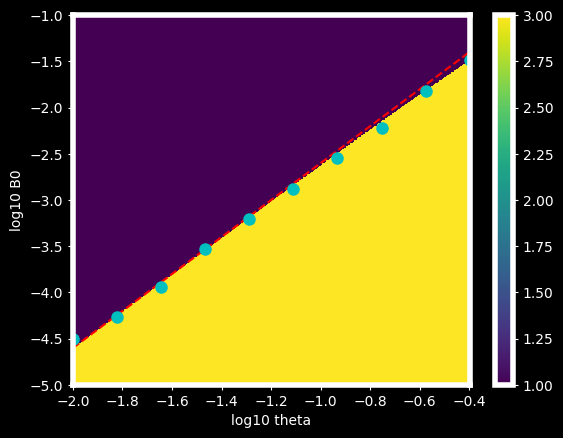

In [ ]:
theta_arr_sim = np.logspace(-2, np.log10(0.4), 10)

plt.figure()
plt.pcolor(np.log10(theta_arr), np.log10(B0_arr), n_real_roots.T)
plt.plot(np.log10(theta_arr), np.log10(0.25) + 2 * np.log10(theta_arr), 'r--')
plt.plot(np.log10(theta_arr_sim), np.log10(thresh_single), 'co', markersize=8)
plt.colorbar()
plt.xlabel('log10 theta')
plt.ylabel('log10 B0')
plt.xlim([-2, np.log10(0.4)])
plt.ylim([-5, -1])


In [ ]:
np.linspace(0, 1, 100)

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

In [ ]:
import jax.numpy as jnp

In [ ]:
jnp.linspace(0, 200, 3)

Array([  0., 100., 200.], dtype=float32)

## Re-doing the single-cell critical threshold prediction with longer time step

In [ ]:
def compute_single_cell_threshold(B0_single, t, θ=0.1, ε=0.0, α=0.00, μ=0.0, ρ=0.0):
  # fixed params
  rtol = 1e-8
  atol = 1e-8
  max_steps = 100000
  solver = dx.Tsit5()
  stepsize_controller = dx.PIDController(rtol=rtol, atol=atol)
  wing = 5

  # single
  A_single = np.zeros_like(B0_single)
  d = 0.0
  for i in tqdm(range(len(B0_single))):
    #print(f'{i+1} of {len(B0_single)}')
    a0 = jnp.zeros(n)
    b0 = jnp.zeros(n)
    b0 = b0.at[n // 2].set(B0_single[i])
    y0 = interleave(a0, b0)
    ode_term = dx.ODETerm(f)
    solution = dx.diffeqsolve(ode_term, solver, args=(θ, ρ, ε, d, α, μ),
                                  t0=t[0], t1=t[-1], dt0=0.001 * (t[1] - t[0]),
                                  y0=y0,
                                  saveat=dx.SaveAt(ts=t),
                                  stepsize_controller=stepsize_controller,
                                  max_steps=max_steps
                                  )
    a, b = unravel(solution.ys.T)
    A_single[i] = a[n // 2, -1]


  return A_single


def measure_threshold(A, B0):
  tmp = B0[:-1]
  threshold = tmp[np.diff(A) == np.max(np.diff(A))]

  return threshold


100%|██████████| 50/50 [00:01<00:00, 27.28it/s]


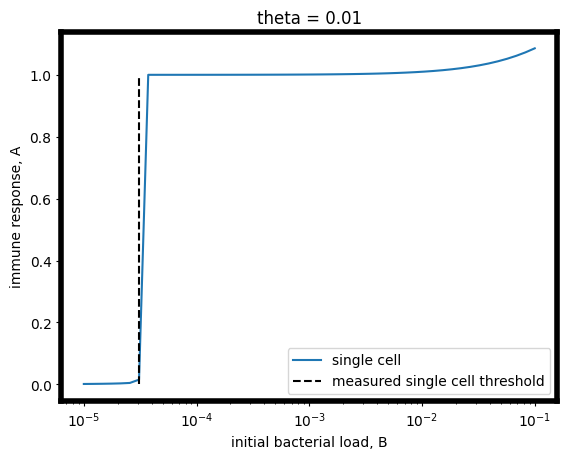

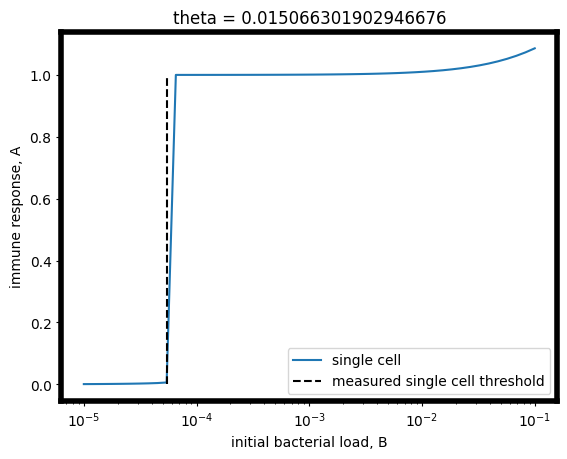

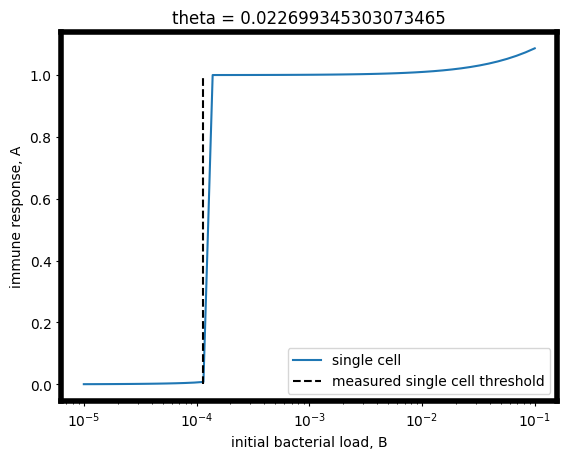

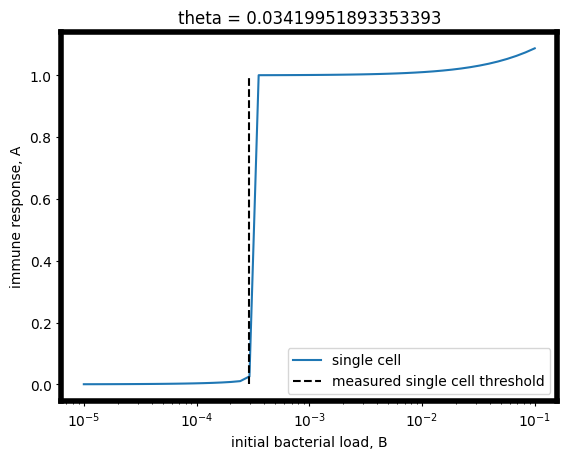

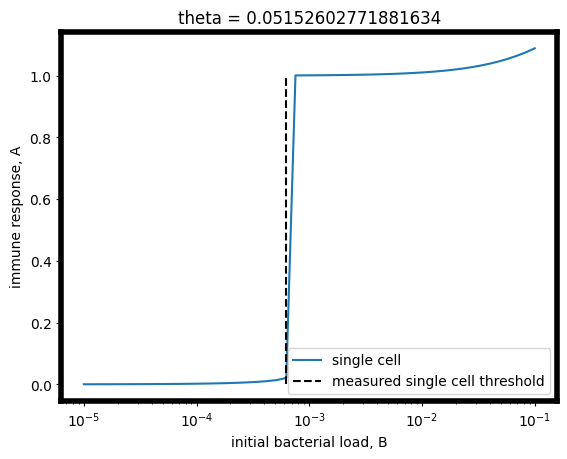

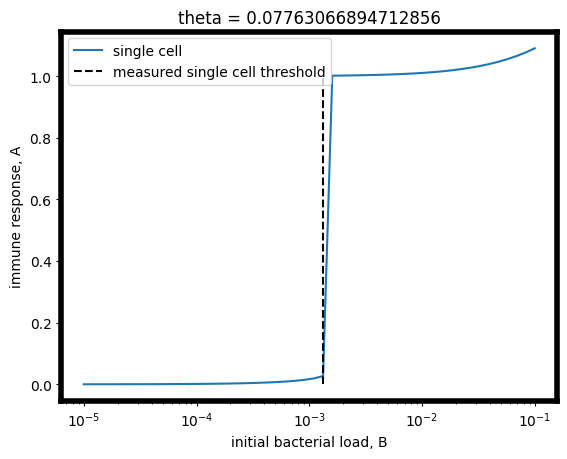

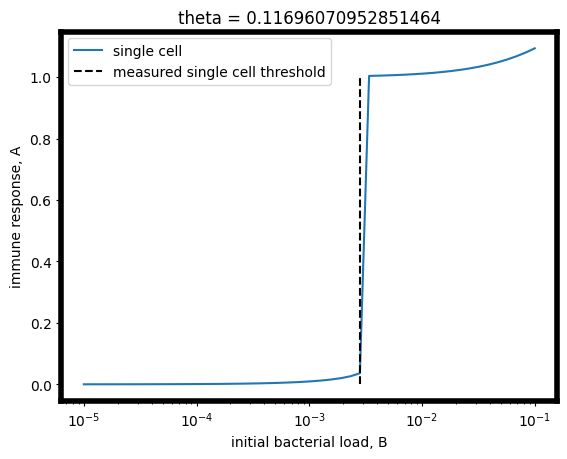

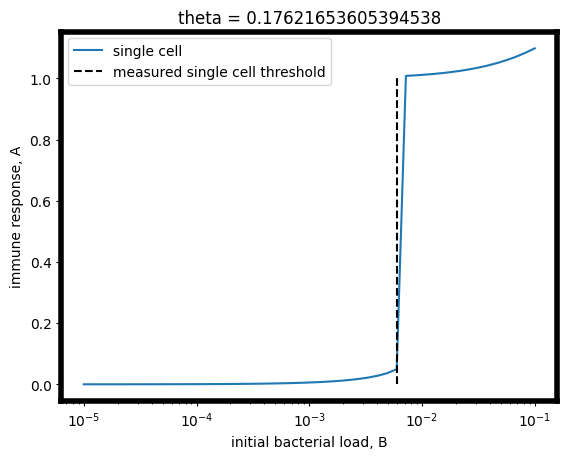

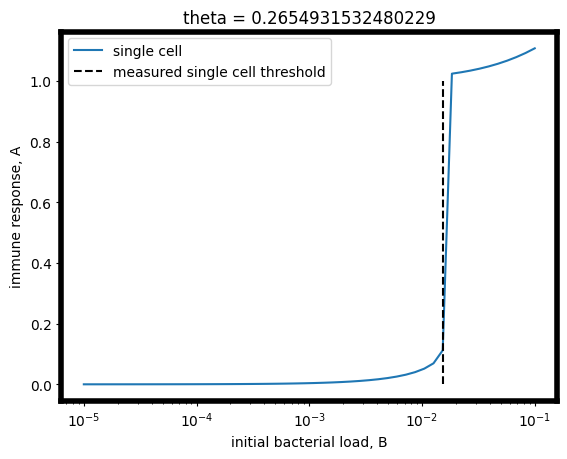

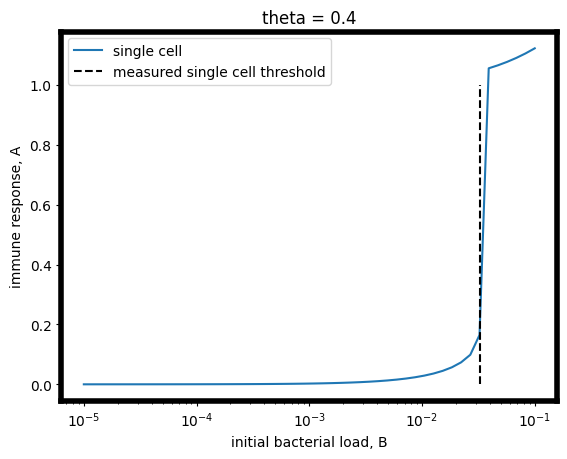

In [ ]:
num_B0s = 50
ε = 0.0
α=0.0
μ=0.0
ρ= 0.0
t = jnp.linspace(0, 1000, 3)
theta_arr = np.logspace(-2, np.log10(0.4), 10)
thresh_single = np.zeros_like(theta_arr)
thresh_spatial = np.zeros_like(theta_arr)
B0_single = np.logspace(-5, -1, num_B0s)

for i in range(len(theta_arr)):
  A_single = compute_single_cell_threshold(B0_single, t, θ=theta_arr[i], ε=ε, α=α, μ=μ, ρ=ρ)

  thresh_single[i] = measure_threshold(A_single, B0_single)

  # one plot with single cell and mean tissue
  plt.figure()
  plt.plot(B0_single, A_single, label='single cell')
  plt.plot(thresh_single[i] * np.ones(5), np.linspace(0, 1, 5), 'k--', label='measured single cell threshold')

  plt.xlabel('initial bacterial load, B')
  plt.ylabel('immune response, A')
  plt.xscale('log')
  plt.legend()
  plt.title(f'theta = {theta_arr[i]}')







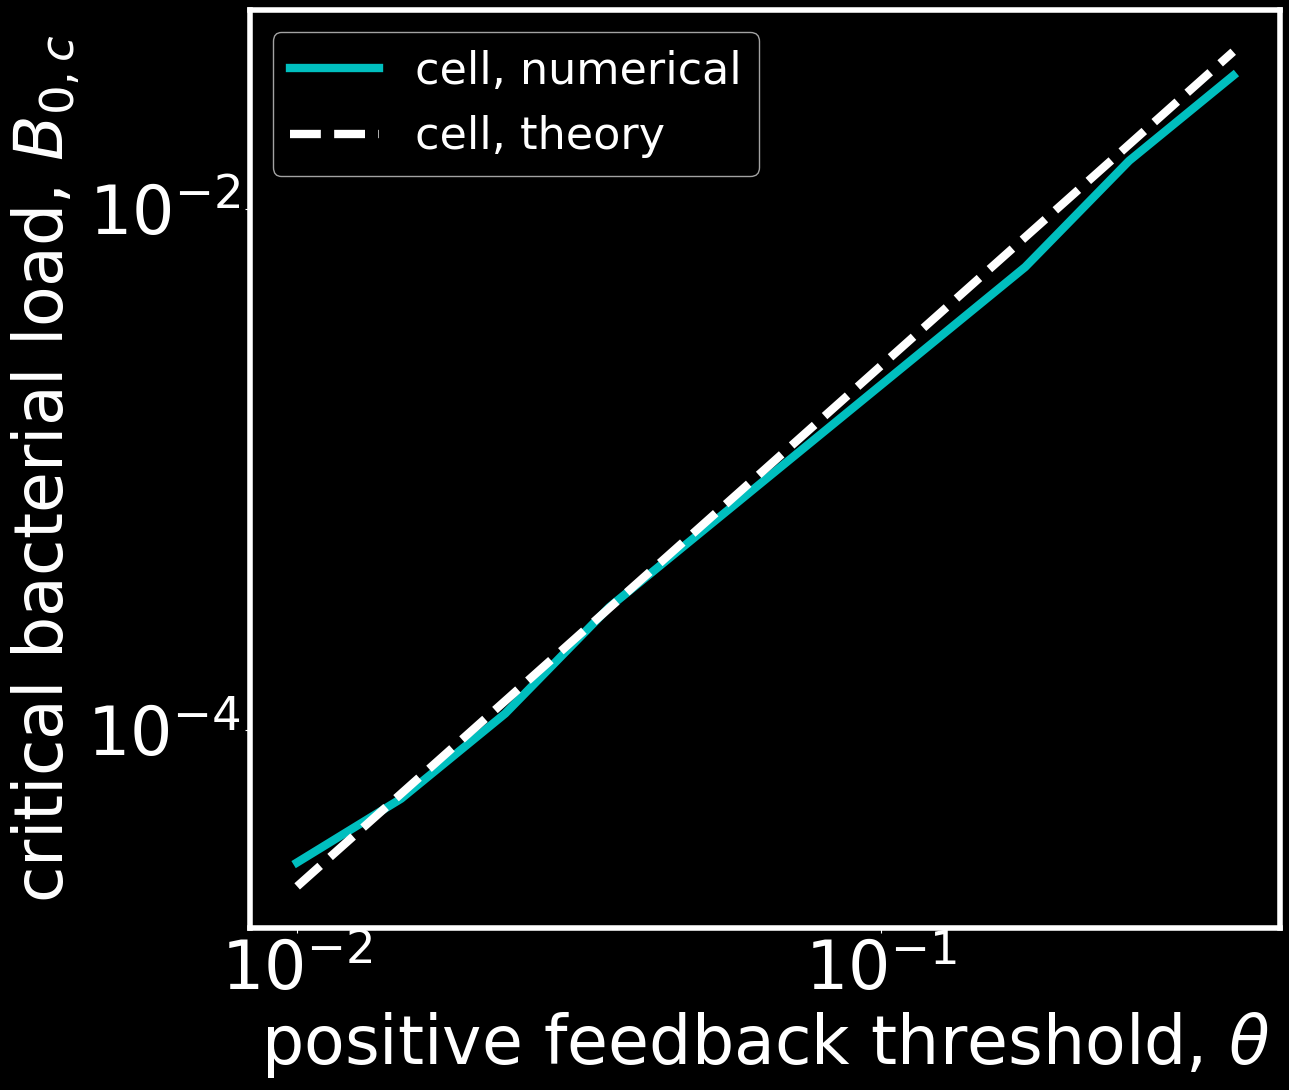

In [ ]:
plt.figure(figsize=(13,11))
plot_from = 0
plt.plot(theta_arr[plot_from:], thresh_single[plot_from:], label='cell, numerical', linewidth=6, color='c')
line_single = theta_arr[plot_from:] ** 2 / 4
plt.plot(theta_arr[plot_from:], line_single, 'w--', label='cell, theory', linewidth=6)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('positive feedback threshold, $\\theta$', fontsize=48)
plt.ylabel('critical bacterial load, $B_{0,c}$', fontsize=48)
plt.minorticks_off()
plt.legend(fontsize=32)
plt.yticks([1e-4, 1e-2], fontsize=48)
plt.xticks(fontsize=48)
plt.tight_layout()
